# Symbolic computation for the BLASSO applied to GMMs with diagonal covariances - Addendum

Romane Giard - 02/2026

Notebook associated with the paper *Riemannian Gradient Descent for Gaussian Mixture Models with unknown diagonal covariances*, by Romane Giard, Yohann De Castro, Roland Denis and Clément Marteau. 

Addendum to the notebook [Symbolic computation for the BLASSO applied to GMMs with diagonal covariances](https://github.com/giardr/blasso_gmm_sympy).

___

**Framework**

In this notebook, we provide additional controls using [SymPy](https://docs.sympy.org/latest/index.html) for the normalized Gaussian kernel $$K_{norm}(x,x')=(2u^2+\tau^2)^{1/4} (2{u'}^2+\tau^2)^{1/4}\frac{e^{-\frac{(t-t')^2}{2(u^2+{u'}^2+\tau^2)}}}{\sqrt{u^2+{u'}^2+\tau^2}}\,,$$ where $\tau>0$, $x=(t,u)$ and $x'=(t',u')$ belong to $\mathbb{R}\times [u_{min},+\infty)$. The parameter $t$ (resp. $u$) represents the mean of a Gaussian (resp. the standard deviation).

We work in a Riemannian geometry framework, and we use the Fisher-Rao metric defined by $\mathfrak{g}_x=\nabla_1\nabla_2 K_{norm}(x,x)$.
One can show that
$$\mathfrak{g}_x=\begin{pmatrix}
      \frac{1}{2u^2+\tau^2} & 0 \\
        0 &  \frac{2u^2}{(2u^2+\tau^2)^2}
\end{pmatrix}\,.$$

In [2]:
from sympy import *
init_printing()
from IPython.display import display, Math

# I - Definitions

We define the kernel for $d=1$, the associated metric tensor and Christoffel symbols. 

Normalized kernel:


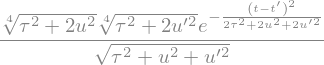

In [ ]:
t_1 , t_2, tau=symbols("t t' tau", real=True)
u_1, u_2=symbols("u u'", positive=True)
K_norm=(2*u_1**2+tau**2)**Rational(1, 4)*(2*u_2**2+tau**2)**Rational(1, 4)*1/sqrt(u_1**2+u_2**2+tau**2)*exp(-(t_1-t_2)**2/(2*(u_1**2+u_2**2+tau**2)))

g_tt=diff(K_norm,t_1,t_2).subs({u_2:u_1,t_2:t_1})
g_uu=diff(K_norm,u_1,u_2).subs({u_2:u_1,t_2:t_1})

christoffel_symbols_t=Matrix([[0,-2*u_1/(tau**2+2*u_1**2)],[-2*u_1/(tau**2+2*u_1**2),0]])
christoffel_symbols_u=Matrix([[1/u_1,0],[0,(tau**2-2*u_1**2)/((tau**2+2*u_1**2)*u_1)]])
Gamma_u_tt=christoffel_symbols_u[0,0]
Gamma_t_tu=christoffel_symbols_t[0,1]
Gamma_u_uu=christoffel_symbols_u[1,1]

print("Normalized kernel:")
K_norm

Metric tensor :


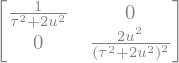

In [4]:
g=Matrix([[g_tt,0],[0,g_uu]])
print("Metric tensor :")
g

Christoffel symbols :


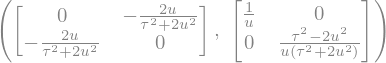

In [5]:
print("Christoffel symbols :")
christoffel_symbols_t, christoffel_symbols_u

# II - Closed-form expressions in dimension $d$

Expressions used in the code of `methods.py`.

**General expressions**

For $x,x' \in \mathbb{R}^d \times [u_{\min},+\infty)^d$, and observing $y= \frac{1}{n} \sum_{i=1}^n \lambda(\cdot - X_i)$ with $\lambda: z \in \mathbb{R}^d \mapsto \frac{e^{-\frac{\|z\|_2^2}{2\tau^2}}}{(2 \pi \tau^2)^{d/2}}$, we have 


$
\begin{aligned}
    K_{\rm norm}(x, x')
&= \langle \Psi \delta_x, \Psi \delta_{x'}\rangle_{\mathbb{L}}  \,, \\
&= \prod_{k=1}^d 
\frac{(2u_k^2 + \tau^2)^{1/4}
(2{u_k'}^2 + \tau^2)^{1/4}}{\sqrt{u_k^2 + {u_k'}^2 + \tau^2}}
    \exp\left(-\frac{(t_k - t_k')^2}{2(u_k^2 + {u_k'}^2 + \tau^2)}\right) \,, \\
\langle \Psi \delta_x, y\rangle_{\mathbb{L}}&= \frac{1}{n} \sum_{i=1}^n Y_i(x) \quad \text{with} \quad Y_i(x)=\prod_{k=1}^d \frac{(2u_k^2+\tau^2)^{1/4}}{(2\pi)^{1/4}\sqrt{u_k^2+\tau^2}} \exp\left(\frac{-(t_k-X_{i,k})^2}{2(u_k^2+\tau^2)}\right) \,, \\
\|y\|_{\mathbb{L}}^2 &= \frac{1}{(2\pi \tau^2)^{d/2}} \frac{1}{n^2}\sum_{i=1}^n \sum_{j=1}^n \exp\left( \frac{-\|X_i - X_j\|_2^2}{2\tau^2} \right) \leq \frac{1}{(2\pi \tau^2)^{d/2}}  \,.
\end{aligned}
$

**Derivatives**

We use the following expressions for the derivatives w.r.t. the kth coordinate of $x$:

$
\begin{aligned}
\partial_{t_k} K_{\rm norm}(x, x') &= \frac{-(t_k-t_k')}{u_k^2+u_k'^2+\tau^2} K_{\rm norm}(x, x') \,, \\
\partial_{u_k} K_{\rm norm}(x, x')&= u_k\left( \frac{(t_k-t_k')^2}{(u_k^2+u_k'^2+\tau^2)^2} - \frac{1}{u_k^2+u_k'^2+\tau^2}+\frac{1}{2u_k^2+\tau^2}\right) K_{\rm norm}(x, x') \,, \\
\partial_{t_k} \langle \Psi \delta_x, y\rangle_{\mathbb{L}} &= \frac{1}{n} \sum_{i=1}^n \frac{-(t_k-X_{i,k})}{u_k^2+\tau^2}    Y_i(x) \,, \\
\partial_{u_k} \langle \Psi \delta_x, y\rangle_{\mathbb{L}}&= \frac{1}{n} \sum_{i=1}^n u_k\left( \frac{(t_k-X_{i,k})^2}{(u_k^2+\tau^2)^2} - \frac{1}{u_k^2+\tau^2}+\frac{1}{2u_k^2+\tau^2}\right)  Y_i(x) \,.
\end{aligned}
$

Below, we check that these expressions are right.

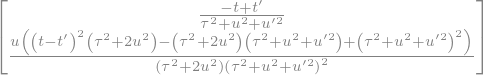

In [6]:
simplify(Matrix([diff(K_norm,t_1),diff(K_norm,u_1)])/K_norm)

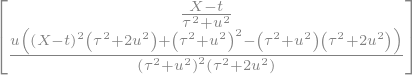

In [7]:
X=symbols("X", real=True)
scalar_prod=(2*u_1**2+tau**2)**Rational(1,4)/((2*pi)**Rational(1,4)*sqrt(u_1**2+tau**2))*exp(-(t_1-X)**2/(2*(u_1**2+tau**2)))
simplify(Matrix([diff(scalar_prod,t_1),diff(scalar_prod,u_1)])/scalar_prod)

# III - Bounds on the euclidean-flavored derivatives

## $B_{02}^e$

$\mathfrak{g}_{t t}^{-2}\partial_{t t}\partial_{t' t'}  K_{\rm norm} (x,x)$

In [25]:
simplify(1/(g_tt**2)*((diff(K_norm,t_1,t_1,t_2,t_2)).subs({t_2:t_1,u_2:u_1})))

$\mathfrak{g}_{t t}^{-1} \mathfrak{g}_{u u}^{-1}\partial_{t u}\partial_{t' u'}  K_{\rm norm} (x,x)$

In [23]:
simplify(1/(g_uu*g_tt)*((diff(K_norm,t_1,u_1,t_2,u_2)).subs({t_2:t_1,u_2:u_1})))

$\mathfrak{g}_{u u}^{-2}\partial_{u u}\partial_{u' u'}  K_{\rm norm} (x,x)$

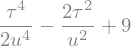

In [24]:
simplify(1/(g_uu**2)*((diff(K_norm,u_1,u_1,u_2,u_2)).subs({t_2:t_1,u_2:u_1})))

## $B_{33}^e$

$
\begin{aligned}
\mathfrak{g}_{t t}^{-3}&\|\partial_{t t t} \Psi \delta_x - \Gamma^{u}{}_{t t}\partial_{u t}\Psi \delta_x\|_{\mathbb{L}}^2 \\
&=\mathfrak{g}_{t t}^{-3} \left(\partial_{t t t} \partial_{t' t' t'} K_{\rm norm} (x,x) + (\Gamma^{u}{}_{t t})^2 \partial_{t u} \partial_{t' u'} K_{\rm norm} (x,x) - 2 \Gamma^{u}{}_{t t}\partial_{t t t}\partial_{t' u'} K_{\rm norm} (x,x) \right)
\end{aligned}
$

In [29]:
simplify(1/(g_tt**3)*(diff(K_norm,t_1,t_1,t_1,t_2,t_2,t_2).subs({t_2:t_1,u_2:u_1})
                      +Gamma_u_tt**2*(diff(K_norm,t_1,u_1,t_2,u_2).subs({t_2:t_1,u_2:u_1}))
                     -2*Gamma_u_tt*(diff(K_norm,t_1,t_1,t_1,t_2,u_2).subs({t_2:t_1,u_2:u_1}))))

$
\begin{aligned}
\mathfrak{g}_{t t}^{-2}&\mathfrak{g}_{u u}^{-1}\|\partial_{t t u} \Psi \delta_x - \Gamma^{t}{}_{t u}\partial_{t t}\Psi \delta_x\|_{\mathbb{L}}^2 \\
&=\mathfrak{g}_{t t}^{-2}\mathfrak{g}_{u u}^{-1} \left(\partial_{t t u} \partial_{t' t' u'} K_{\rm norm} (x,x) + (\Gamma^{t}{}_{t u})^2 \partial_{t t} \partial_{t' t'} K_{\rm norm} (x,x) - 2 \Gamma^{t}{}_{t u}\partial_{t t u}\partial_{t' t'} K_{\rm norm} (x,x) \right)
\end{aligned}
$

In [30]:
simplify(1/(g_tt**2*g_uu)*(diff(K_norm,t_1,t_1,u_1,t_2,t_2,u_2).subs({t_2:t_1,u_2:u_1})
                      +Gamma_t_tu**2*(diff(K_norm,t_1,t_1,t_2,t_2).subs({t_2:t_1,u_2:u_1}))
                     -2*Gamma_t_tu*(diff(K_norm,t_1,t_1,u_1,t_2,t_2).subs({t_2:t_1,u_2:u_1}))))

$
\begin{aligned}
\mathfrak{g}_{t t}^{-1}&\mathfrak{g}_{u u}^{-2}\|\partial_{t u u} \Psi \delta_x - \Gamma^{t}{}_{t u}\partial_{t u}\Psi \delta_x\|_{\mathbb{L}}^2 \\
&=\mathfrak{g}_{t t}^{-1}\mathfrak{g}_{u u}^{-2} \left(\partial_{t u u} \partial_{t' u' u'} K_{\rm norm} (x,x) + (\Gamma^{t}{}_{t u})^2 \partial_{t u} \partial_{t' u'} K_{\rm norm} (x,x) - 2 \Gamma^{t}{}_{t u}\partial_{t u u}\partial_{t' u'} K_{\rm norm} (x,x) \right)
\end{aligned}
$

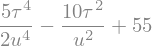

In [13]:
simplify(1/(g_tt*g_uu**2)*(diff(K_norm,t_1,u_1,u_1,t_2,u_2,u_2).subs({t_2:t_1,u_2:u_1})
                      +Gamma_t_tu**2*(diff(K_norm,t_1,u_1,t_2,u_2).subs({t_2:t_1,u_2:u_1}))
                     -2*Gamma_t_tu*(diff(K_norm,t_1,u_1,u_1,t_2,u_2).subs({t_2:t_1,u_2:u_1}))))

$
\begin{aligned}
\mathfrak{g}_{t t}^{-1}&\mathfrak{g}_{u u}^{-2}\|\partial_{t u u} \Psi \delta_x - \Gamma^{u}{}_{u u}\partial_{t u}\Psi \delta_x\|_{\mathbb{L}}^2 \\
&=\mathfrak{g}_{t t}^{-1}\mathfrak{g}_{u u}^{-2} \left(\partial_{t u u} \partial_{t' u' u'} K_{\rm norm} (x,x) + (\Gamma^{u}{}_{u u})^2 \partial_{t u} \partial_{t' u'} K_{\rm norm} (x,x) - 2 \Gamma^{u}{}_{u u}\partial_{t u u}\partial_{t' u'} K_{\rm norm} (x,x) \right)
\end{aligned}
$

In [14]:
simplify(1/(g_tt*g_uu**2)*(diff(K_norm,t_1,u_1,u_1,t_2,u_2,u_2).subs({t_2:t_1,u_2:u_1})
                      +Gamma_u_uu**2*(diff(K_norm,t_1,u_1,t_2,u_2).subs({t_2:t_1,u_2:u_1}))
                     -2*Gamma_u_uu*(diff(K_norm,t_1,u_1,u_1,t_2,u_2).subs({t_2:t_1,u_2:u_1}))))

$
\begin{aligned}
\mathfrak{g}_{u u}^{-3}&\|\partial_{u u u} \Psi \delta_x - \Gamma^{u}{}_{u u}\partial_{u u}\Psi \delta_x\|_{\mathbb{L}}^2 \\
&=\mathfrak{g}_{u u}^{-3} \left(\partial_{u u u} \partial_{u' u' u'} K_{\rm norm} (x,x) + (\Gamma^{u}{}_{u u})^2 \partial_{u u} \partial_{u' u'} K_{\rm norm} (x,x) - 2 \Gamma^{u}{}_{u u}\partial_{u u u}\partial_{u' u'} K_{\rm norm} (x,x) \right)
\end{aligned}
$

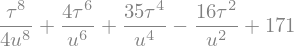

In [15]:
simplify(1/(g_uu**3)*(diff(K_norm,u_1,u_1,u_1,u_2,u_2,u_2).subs({t_2:t_1,u_2:u_1})
                      +Gamma_u_uu**2*(diff(K_norm,u_1,u_1,u_2,u_2).subs({t_2:t_1,u_2:u_1}))
                     -2*Gamma_u_uu*(diff(K_norm,u_1,u_1,u_1,u_2,u_2).subs({t_2:t_1,u_2:u_1}))))